# Netflix Reviews with NLP

In this notebook, we'll explore methods for analyzing text using Netflix Reviews data.

# Import packages

In [1]:
# data processing
import numpy as np
import pandas as pd

# text processing and NLP
import nltk
from textblob import TextBlob

# gensim for topic modeling
import gensim
from gensim import corpora
from gensim.utils import simple_preprocess

# viz
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from wordcloud import WordCloud, STOPWORDS
import seaborn as sns
import matplotlib.pyplot as plt

# misc
import re
import warnings
warnings.filterwarnings("ignore")

print('Packages successfully imported.')

Packages successfully imported.


# Load data

In [2]:
import os
# Kaggle'da ve yerelde çalışır: dosya hangi yoldaysa onu kullanır
candidates = ['/kaggle/input/netflix-reviews-playstore-daily-updated/netflix_reviews.csv',
              '../netflix_reviews.csv', 'netflix_reviews.csv']
path = next((p for p in candidates if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError('netflix_reviews.csv bulunamadı. Kaggle veri setini indirip proje köküne koyun.')
df = pd.read_csv(path)

print("Shape of the dataset:", df.shape)
print("Columns in the dataset:", df.columns)

df.head()

Shape of the dataset: (113068, 8)
Columns in the dataset: Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,efd00499-5e00-49b5-9f32-bc7177ac5ca6,Mikel Magnusson,Netfix Canada forced my wife into a screen tha...,1,0,8.93.1 build 4 50540,2024-06-14 21:47:49,8.93.1 build 4 50540
1,be0d97e1-7de1-4f07-b493-35a53098b5a4,John McDevitt,I use this app until it asks if I'm still ther...,2,0,8.119.0 build 11 50706,2024-06-14 21:33:01,8.119.0 build 11 50706
2,8970dbcd-d75f-4016-bb93-efa5de3ef9e6,Mayur Savaliya,Boycott Netflix from Bharat,1,1,8.14.0 build 5 40129,2024-06-14 21:31:07,8.14.0 build 5 40129
3,a288bc3c-8a90-42d3-b585-1c8078faa96c,Magdalena Glessing,Little good movies and a lot of wonderful TV s...,5,0,8.118.1 build 10 50703,2024-06-14 21:27:26,8.118.1 build 10 50703
4,c388a806-0795-4812-b04e-5b2cdf327157,Elizabeth Turner,"New to this but, so far smooth sailing.app is ...",5,0,8.118.1 build 10 50703,2024-06-14 21:22:13,8.118.1 build 10 50703


# Pre-processing

In [3]:
def preprocess_text(text):
    if isinstance(text, float):
        return ""
    text = text.lower()  # lowercase
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.strip()  # remove leading/trailing whitespace
    return text

In [4]:
df['content_c'] = df['content'].apply(preprocess_text)
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,content_c
0,efd00499-5e00-49b5-9f32-bc7177ac5ca6,Mikel Magnusson,Netfix Canada forced my wife into a screen tha...,1,0,8.93.1 build 4 50540,2024-06-14 21:47:49,8.93.1 build 4 50540,netfix canada forced my wife into a screen tha...
1,be0d97e1-7de1-4f07-b493-35a53098b5a4,John McDevitt,I use this app until it asks if I'm still ther...,2,0,8.119.0 build 11 50706,2024-06-14 21:33:01,8.119.0 build 11 50706,i use this app until it asks if im still there...
2,8970dbcd-d75f-4016-bb93-efa5de3ef9e6,Mayur Savaliya,Boycott Netflix from Bharat,1,1,8.14.0 build 5 40129,2024-06-14 21:31:07,8.14.0 build 5 40129,boycott netflix from bharat
3,a288bc3c-8a90-42d3-b585-1c8078faa96c,Magdalena Glessing,Little good movies and a lot of wonderful TV s...,5,0,8.118.1 build 10 50703,2024-06-14 21:27:26,8.118.1 build 10 50703,little good movies and a lot of wonderful tv s...
4,c388a806-0795-4812-b04e-5b2cdf327157,Elizabeth Turner,"New to this but, so far smooth sailing.app is ...",5,0,8.118.1 build 10 50703,2024-06-14 21:22:13,8.118.1 build 10 50703,new to this but so far smooth sailingapp is ea...


In [5]:
df.isnull()
total_null_values = df.isnull().sum().sum()
print("Total null values in the DataFrame:", total_null_values)

Total null values in the DataFrame: 32985


In [6]:
df.fillna('', inplace=True)

In [7]:
df['at'] = pd.to_datetime(df['at'])

In [8]:
df = df[['content_c', 'score', 'reviewId', 'at']]
df.head()

,content_c,score,reviewId,at
0,netfix canada forced my wife into a screen tha...,1,efd00499-5e00-49b5-9f32-bc7177ac5ca6,2024-06-14 21:47:49
1,i use this app until it asks if im still there...,2,be0d97e1-7de1-4f07-b493-35a53098b5a4,2024-06-14 21:33:01
2,boycott netflix from bharat,1,8970dbcd-d75f-4016-bb93-efa5de3ef9e6,2024-06-14 21:31:07
3,little good movies and a lot of wonderful tv s...,5,a288bc3c-8a90-42d3-b585-1c8078faa96c,2024-06-14 21:27:26
4,new to this but so far smooth sailingapp is ea...,5,c388a806-0795-4812-b04e-5b2cdf327157,2024-06-14 21:22:13


In [9]:
print("Earliest review date:", df['at'].min())
print("Latest review date:", df['at'].max())

Earliest review date: 2018-09-12 07:22:12
Latest review date: 2024-06-14 21:47:49


# EDA

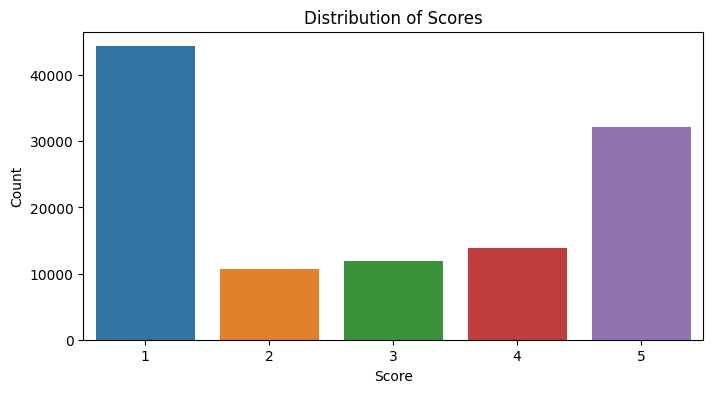

In [10]:
# analyzing score distribution
score_counts = df.score.value_counts().sort_index()
plt.figure(figsize=(8, 4))
sns.barplot(x=score_counts.index, y=score_counts.values)
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Distribution of Scores')
plt.show()


NLP

In [11]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

In [12]:
df['sentiment'] = df['content_c'].apply(get_sentiment)
df['sentiment_label'] = df['sentiment'].apply(lambda x: 'positive' if x > 0.1 else ('negative' if x < -0.1 else 'neutral'))

In [13]:
df[['content_c', 'score', 'sentiment_label']]

,content_c,score,sentiment_label
0,netfix canada forced my wife into a screen tha...,1,neutral
1,i use this app until it asks if im still there...,2,negative
2,boycott netflix from bharat,1,neutral
3,little good movies and a lot of wonderful tv s...,5,positive
4,new to this but so far smooth sailingapp is ea...,5,positive
...,...,...,...
113063,i really like it there are so many movies and ...,5,positive
113064,i love netflix i always enjoy my time using it,5,positive
113065,sound quality is very slow of movies,1,neutral
113066,rate is very expensive bcos we see netflix sun...,1,negative


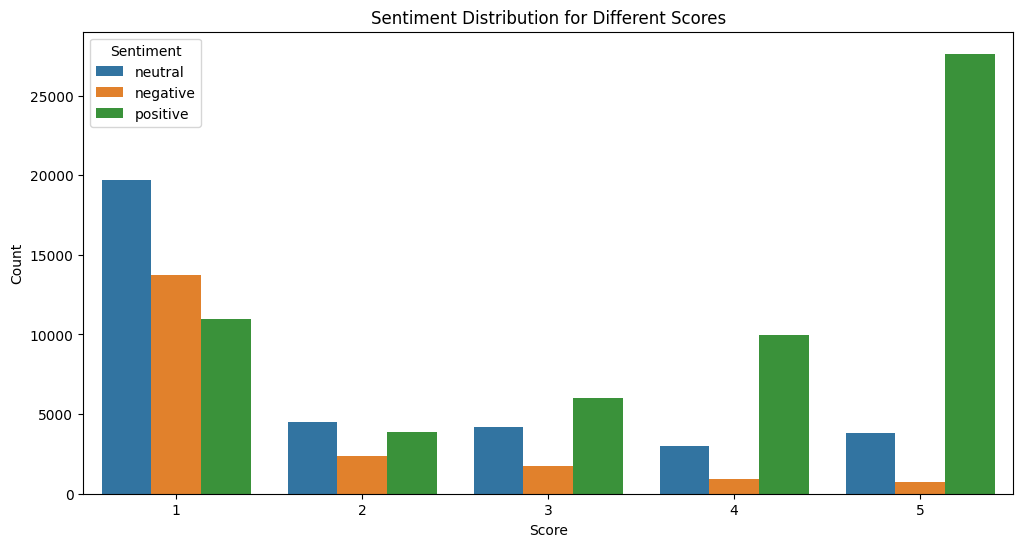

In [14]:
# sentiment distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='score', hue='sentiment_label')
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Sentiment Distribution for Different Scores')
plt.legend(title='Sentiment')
plt.show()

Sentiment analysis accurately identify positives and negatives.

# Word cloud 

Analyzing negative reviews

In [15]:
# add our list of stopwords
stopwords = set(STOPWORDS)
stopwords.update(['netflix', 'movie', 'show', 'time', 'app', 'series', 'phone']) # creating a custom list based on domain knowledge

In [16]:
negative_reviews = ' '.join(df[df['sentiment_label'] == 'negative']['content_c'])

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(negative_reviews)

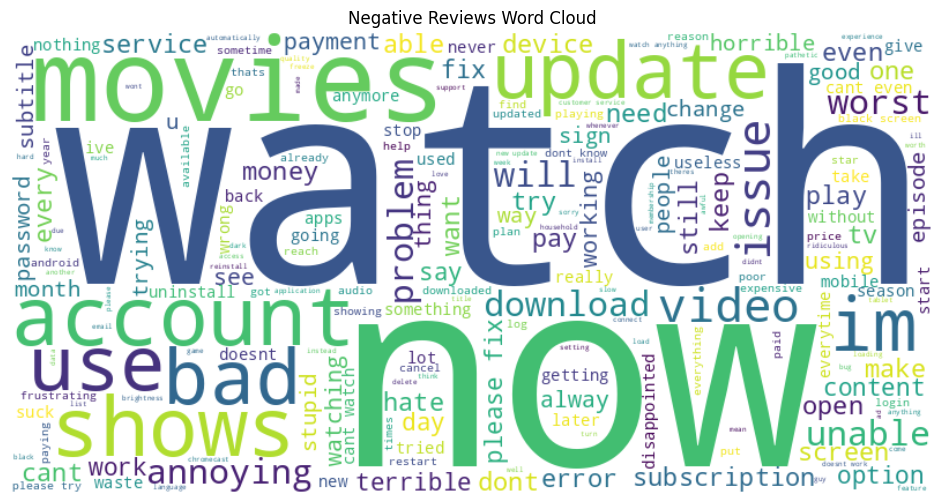

In [17]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews Word Cloud')
plt.show()

Word cloud reveals common issues like black screen, service glitches, downloads, pricing, and membership.

# Topic modeling 

Scope: negative reviews

In [18]:
# preprocess text data in content_c (negative reviews only)
texts = [preprocess_text(text) for text in df[df['sentiment_label']=='negative']['content_c']]

In [19]:
texts[:5]

['i use this app until it asks if im still there then i move on to another service thats less infuriating i already sporadically subscribe dont make it rarely give us the options weve asked for and fire whoever ruined the witcher im sick of these services it costs as much as cable but they get to sell your data change their prices at a whim put quality behind a paywall make bad bets on the future of gaming and pass off failure and costs as its a hard economic time for everyone',
 'this app is starting to get annoying i download movies films i have all my settings to no subtitles but i get subtitles each and every time shouldnt need to keep restarting and keep keep clearing cache each time i want to watch a programme or film',
 'keeps overriding my brightness controls which is incredibly annoying also told me im not in the same family as my dad which is news to me',
 'worst app ever it take to much steps to just sign in waste of time',
 'useless whats the point of mobile app if i cant t

In [20]:
tokenized_texts = [simple_preprocess(text) for text in texts]
tokenized_texts = [[word for word in doc if word not in stopwords] for doc in tokenized_texts] # remove stopwords

# create dict and corpus
dictionary = corpora.Dictionary(tokenized_texts)
corpus = [dictionary.doc2bow(tokens) for tokens in tokenized_texts]

In [21]:
tokenized_texts[0][:5]

['use', 'asks', 'im', 'still', 'move']

# LDA model 

Extract topics that cause dissastisfaction among users

In [22]:
# build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=5, passes=5, workers=2)

In [23]:
# print topics
topics = lda_model.print_topics(-1)
for idx, topic in topics:
    print(f"Topic {idx}: {topic}")

Topic 0: 0.016*"movies" + 0.014*"dont" + 0.013*"watch" + 0.012*"bad" + 0.012*"cant" + 0.011*"hate" + 0.010*"im" + 0.009*"want" + 0.009*"worst" + 0.009*"use"
Topic 1: 0.017*"cant" + 0.016*"payment" + 0.015*"worst" + 0.014*"service" + 0.013*"account" + 0.012*"bad" + 0.012*"money" + 0.012*"even" + 0.012*"please" + 0.011*"unable"
Topic 2: 0.021*"movies" + 0.015*"shows" + 0.014*"new" + 0.013*"update" + 0.012*"please" + 0.011*"watch" + 0.009*"bad" + 0.008*"boring" + 0.007*"tv" + 0.007*"really"
Topic 3: 0.015*"im" + 0.015*"now" + 0.013*"account" + 0.010*"service" + 0.009*"cant" + 0.009*"use" + 0.009*"update" + 0.008*"watch" + 0.008*"even" + 0.006*"dont"
Topic 4: 0.021*"watch" + 0.018*"screen" + 0.015*"cant" + 0.012*"fix" + 0.012*"play" + 0.012*"please" + 0.011*"video" + 0.011*"even" + 0.011*"annoying" + 0.010*"open"


Visualize extract topics from LDA model

In [24]:
# visualize topics
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

# Credits

Special thanks to [Zul](https://www.kaggle.com/zulqarnainalipk) for his contributions to this notebook.